<a href="https://colab.research.google.com/github/LycanVenom1225/Data-analytics-course-/blob/main/Capstone_NG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import requests
github= "https://raw.githubusercontent.com/LycanVenom1225/Data-analytics-course-/main/DOHMH_New_York_City_Restaurant_Inspection_Results_20260528_V2.xlsx"
response=requests.get(github)
local_filename = "downloaded_file.xlsx"
with open(local_filename, "wb") as f:
    f.write(response.content)
    df = pd.read_excel(local_filename)
df.head(40)

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,VIOLATION CODE,VIOLATION DESCRIPTION,CRITICAL FLAG,SCORE,GRADE,GRADE DATE,RECORD DATE,INSPECTION TYPE,Latitude,Longitude
0,50159080,BX CREPES & WAFFLES,Bronx,3532,WHITE PLAINS ROAD,10467.0,3479162503,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.878016,-73.866094
1,50172771,AZ&G INC,Queens,133-33,39 AVENUE,11354.0,7188198818,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.759110,-73.834161
2,50173812,EARTHBAR,Brooklyn,246,BEDFORD AVENUE,11249.0,3474220302,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.715847,-73.959865
3,50171729,KATI SHOP,0,100,PARK AVE,7024.0,9178681496,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,NaN,NaN
4,50180551,D LA PARA PICA POLLO BRONX,Bronx,3010,JEROME AVENUE,10468.0,3478428671,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.873931,-73.889110
5,50182814,MR. COSTENITO INC.,Brooklyn,1525,GATES AVENUE,11237.0,6462503535,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.698954,-73.912776
6,50186151,LE LOUP,Queens,22-80,STEINWAY ST,11105.0,3476523777,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.771577,-73.907622
7,50178329,APARTMENT RA'EL,Brooklyn,1124,BEDFORD AVENUE,11216.0,9176456228,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.686136,-73.954474
8,50176305,FIRESIDE CAFE INC.,Brooklyn,1957,86 STREET,11214.0,9173598660,NaN,1900-01-01,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaT,2026-05-27 06:00:20,NaN,40.605122,-73.999096
9,50149829,LA ESQUINA,0,421,8TH AVE,10116.0,2129207434,Mexican,2025-08-26,Violations were cited in the following area(s).,02B,Hot TCS food item not held at or above 140 °F.,Critical,12.0,A,2025-08-26,2026-05-27 06:00:15,Cycle Inspection / Initial Inspection,NaN,NaN


In [26]:
import seaborn as sns

In [4]:
df['CUISINE DESCRIPTION']=df['CUISINE DESCRIPTION'].fillna("No Description")

In [5]:
df['GRADE']=df['GRADE'].fillna("No Grade")

In [6]:
dfBORO=df[df["BORO"].str.contains("0").eq(False)]


In [7]:
dfBORO.dtypes

,0
CAMIS,int64
DBA,object
BORO,object
BUILDING,object
STREET,object
ZIPCODE,float64
PHONE,object
CUISINE DESCRIPTION,object
INSPECTION DATE,datetime64[ns]
ACTION,object


In [8]:
dfflag = dfBORO.groupby(["DBA","BUILDING","STREET","BORO","CUISINE DESCRIPTION","CRITICAL FLAG"]).size().reset_index(name='count_of_flags')
dfflag.head()

,DBA,BUILDING,STREET,BORO,CUISINE DESCRIPTION,CRITICAL FLAG,count_of_flags
0,#1 GARDEN CHINESE RESTAURANT,221,PROSPECT PARK WEST,Brooklyn,Chinese,Critical,4
1,#1 GARDEN CHINESE RESTAURANT,221,PROSPECT PARK WEST,Brooklyn,Chinese,Not Critical,4
2,#1 SABOR LATINO RESTAURANT,4120,WHITE PLAINS ROAD,Bronx,Latin American,Critical,17
3,#1 SABOR LATINO RESTAURANT,4120,WHITE PLAINS ROAD,Bronx,Latin American,Not Critical,8
4,$1 SLICE PIZZA,3414,JEROME AVENUE,Bronx,Pizza,Critical,12


In [9]:
dfflag=dfflag[dfflag["CRITICAL FLAG"].str.contains("Not Applicable").eq(False)]

In [10]:

dfflag.groupby(["CRITICAL FLAG"])["BORO"].count()


,BORO
CRITICAL FLAG,
Critical,15116
Not Critical,15092


In [11]:
flagpivot=pd.pivot_table(dfflag,index=["DBA","BUILDING","STREET","BORO","CUISINE DESCRIPTION"],columns="CRITICAL FLAG",values="count_of_flags",aggfunc="sum")
flagpivot.head()

,,,,CRITICAL FLAG,Critical,Not Critical
DBA,BUILDING,STREET,BORO,CUISINE DESCRIPTION,,
#1 GARDEN CHINESE RESTAURANT,221,PROSPECT PARK WEST,Brooklyn,Chinese,4.0,4.0
#1 SABOR LATINO RESTAURANT,4120,WHITE PLAINS ROAD,Bronx,Latin American,17.0,8.0
$1 SLICE PIZZA,3414,JEROME AVENUE,Bronx,Pizza,12.0,7.0
$1.50 UTICA HOT PIZZA,1127,EASTERN PARKWAY,Brooklyn,Pizza,14.0,7.0
$1.50 HOT PIZZA,1751,FULTON STREET,Brooklyn,Pizza,2.0,1.0


In [12]:
flagpivot.columns = [f"{col[0]}_{col[1]}" for col in flagpivot.columns]
flag= pd.DataFrame(flagpivot.to_records())
flag.head()

,DBA,BUILDING,STREET,BORO,CUISINE DESCRIPTION,C_r,N_o
0,#1 GARDEN CHINESE RESTAURANT,221,PROSPECT PARK WEST,Brooklyn,Chinese,4.0,4.0
1,#1 SABOR LATINO RESTAURANT,4120,WHITE PLAINS ROAD,Bronx,Latin American,17.0,8.0
2,$1 SLICE PIZZA,3414,JEROME AVENUE,Bronx,Pizza,12.0,7.0
3,$1.50 UTICA HOT PIZZA,1127,EASTERN PARKWAY,Brooklyn,Pizza,14.0,7.0
4,$1.50 HOT PIZZA,1751,FULTON STREET,Brooklyn,Pizza,2.0,1.0


In [13]:
flag=flag.rename(columns={"C_r":"Critical","N_o":"Not Critical"})

In [91]:
flagtotal=flagfit["DBA"].count()
print(flagtotal)

2990


In [70]:
flagfit=flag[(flag['CUISINE DESCRIPTION'].str.contains("Caribbean")) | (flag['CUISINE DESCRIPTION'].str.contains("Italian")) | (flag['CUISINE DESCRIPTION'].str.contains("Mexican")) | (flag['CUISINE DESCRIPTION'].str.contains("Latin American")) | (flag['CUISINE DESCRIPTION'].str.contains("Thai")) | (flag['CUISINE DESCRIPTION'].str.contains("Indian"))]
flagfit.head()

,DBA,BUILDING,STREET,BORO,CUISINE DESCRIPTION,Critical,Not Critical
1,#1 SABOR LATINO RESTAURANT,4120,WHITE PLAINS ROAD,Bronx,Latin American,17.0,8.0
12,1 QUETZAL,7210,NEW UTRECHT AVENUE,Brooklyn,Mexican,3.0,3.0
19,10 02 LOUNGE AND RESTAURANT,806,EAST TREMONT AVENUE,Bronx,Caribbean,4.0,4.0
22,100'S RESTAURANT AND GRILL,127-19,MERRICK BOULEVARD,Queens,Caribbean,4.0,4.0
34,11 PARISHES RESTAURANT,1081,FLATBUSH AVENUE,Brooklyn,Caribbean,5.0,3.0


In [75]:
maxboro=flagfit.groupby(["BORO","CUISINE DESCRIPTION"],as_index=False).agg({"Critical":"sum","Not Critical":"sum","DBA":"count"})
maxboro.head()

,BORO,CUISINE DESCRIPTION,Critical,Not Critical,DBA
0,Bronx,Caribbean,874.0,675.0,111
1,Bronx,Indian,71.0,59.0,13
2,Bronx,Italian,290.0,232.0,39
3,Bronx,Latin American,1348.0,1100.0,186
4,Bronx,Mexican,811.0,761.0,149


In [76]:
maxboro["Percent Critical"]=(maxboro["Critical"]/maxboro["DBA"])*100
maxboro.head()


,BORO,CUISINE DESCRIPTION,Critical,Not Critical,DBA,Percent Critical
0,Bronx,Caribbean,874.0,675.0,111,787.387387
1,Bronx,Indian,71.0,59.0,13,546.153846
2,Bronx,Italian,290.0,232.0,39,743.589744
3,Bronx,Latin American,1348.0,1100.0,186,724.731183
4,Bronx,Mexican,811.0,761.0,149,544.295302


In [77]:
maxboro=maxboro.rename(columns={"DBA":"Total Restaurants"})
maxboro.head()

,BORO,CUISINE DESCRIPTION,Critical,Not Critical,Total Restaurants,Percent Critical
0,Bronx,Caribbean,874.0,675.0,111,787.387387
1,Bronx,Indian,71.0,59.0,13,546.153846
2,Bronx,Italian,290.0,232.0,39,743.589744
3,Bronx,Latin American,1348.0,1100.0,186,724.731183
4,Bronx,Mexican,811.0,761.0,149,544.295302


In [54]:
maxBC=flagfit.loc[flagfit.groupby('CUISINE DESCRIPTION',)['Critical'].idxmax()]
maxBC.head(20)

,DBA,BUILDING,STREET,BORO,CUISINE DESCRIPTION,Critical,Not Critical
14518,TRIPLE DEUCE,3601,BOSTON ROAD,Bronx,Caribbean,35.0,23.0
696,ASIAN KABAB & CURRY,496,CRESCENT STREET,Brooklyn,Indian,40.0,27.0
5304,FUZI PASTA CO.,68-26,FRESH MEADOW LANE,Queens,Italian,29.0,12.0
8229,LINDA AZOGUENITA BAKERY & RESTAURANT,51-01,108 STREET,Queens,Latin American,42.0,20.0
13566,TAQUERIA COATZINGO,76-05,ROOSEVELT AVENUE,Queens,Mexican,36.0,17.0
802,AYADA THAI RESTAURANT,77-08,WOODSIDE AVENUE,Queens,Thai,31.0,16.0


In [56]:
MinBC=flagfit.loc[flagfit.groupby('CUISINE DESCRIPTION',)['Critical'].idxmin()]
MinBC.head(20)

,DBA,BUILDING,STREET,BORO,CUISINE DESCRIPTION,Critical,Not Critical
134,7 SPICES,906908,E GUNHILL RD,Bronx,Caribbean,1.0,6.0
845,BAANI SWEETS & CATERING,113-11,101 AVENUE,Queens,Indian,1.0,2.0
197,A & S Cucina (Boogie Down Food Hall inside Foo...,610,EXTERIOR STREET,Bronx,Italian,1.0,1.0
299,AGENDA,28-18,31 STREET,Queens,Latin American,1.0,3.0
407,ALMA,187,COLUMBIA STREET,Brooklyn,Mexican,1.0,1.0
803,AYAM,40-13,35 AVENUE,Queens,Thai,1.0,2.0


In [82]:
MaxBC=flagfit.loc[flagfit.groupby('CUISINE DESCRIPTION',)['Critical'].idxmax()]
MaxBC.head(20)

,DBA,BUILDING,STREET,BORO,CUISINE DESCRIPTION,Critical,Not Critical
14518,TRIPLE DEUCE,3601,BOSTON ROAD,Bronx,Caribbean,35.0,23.0
696,ASIAN KABAB & CURRY,496,CRESCENT STREET,Brooklyn,Indian,40.0,27.0
5304,FUZI PASTA CO.,68-26,FRESH MEADOW LANE,Queens,Italian,29.0,12.0
8229,LINDA AZOGUENITA BAKERY & RESTAURANT,51-01,108 STREET,Queens,Latin American,42.0,20.0
13566,TAQUERIA COATZINGO,76-05,ROOSEVELT AVENUE,Queens,Mexican,36.0,17.0
802,AYADA THAI RESTAURANT,77-08,WOODSIDE AVENUE,Queens,Thai,31.0,16.0


In [61]:
from numpy import astype
maxBC[["Critical","Not Critical"]]=maxBC[["Critical","Not Critical"]].astype("Int64")

In [81]:
cuimaxmean=flagfit.groupby(["BORO"],as_index=False)["Critical"].mean()
cuimaxmean.head(90)


,BORO,Critical
0,Bronx,6.945344
1,Brooklyn,6.866611
2,Queens,7.704839


In [93]:
ck=len(flag)
print(ck)

15595


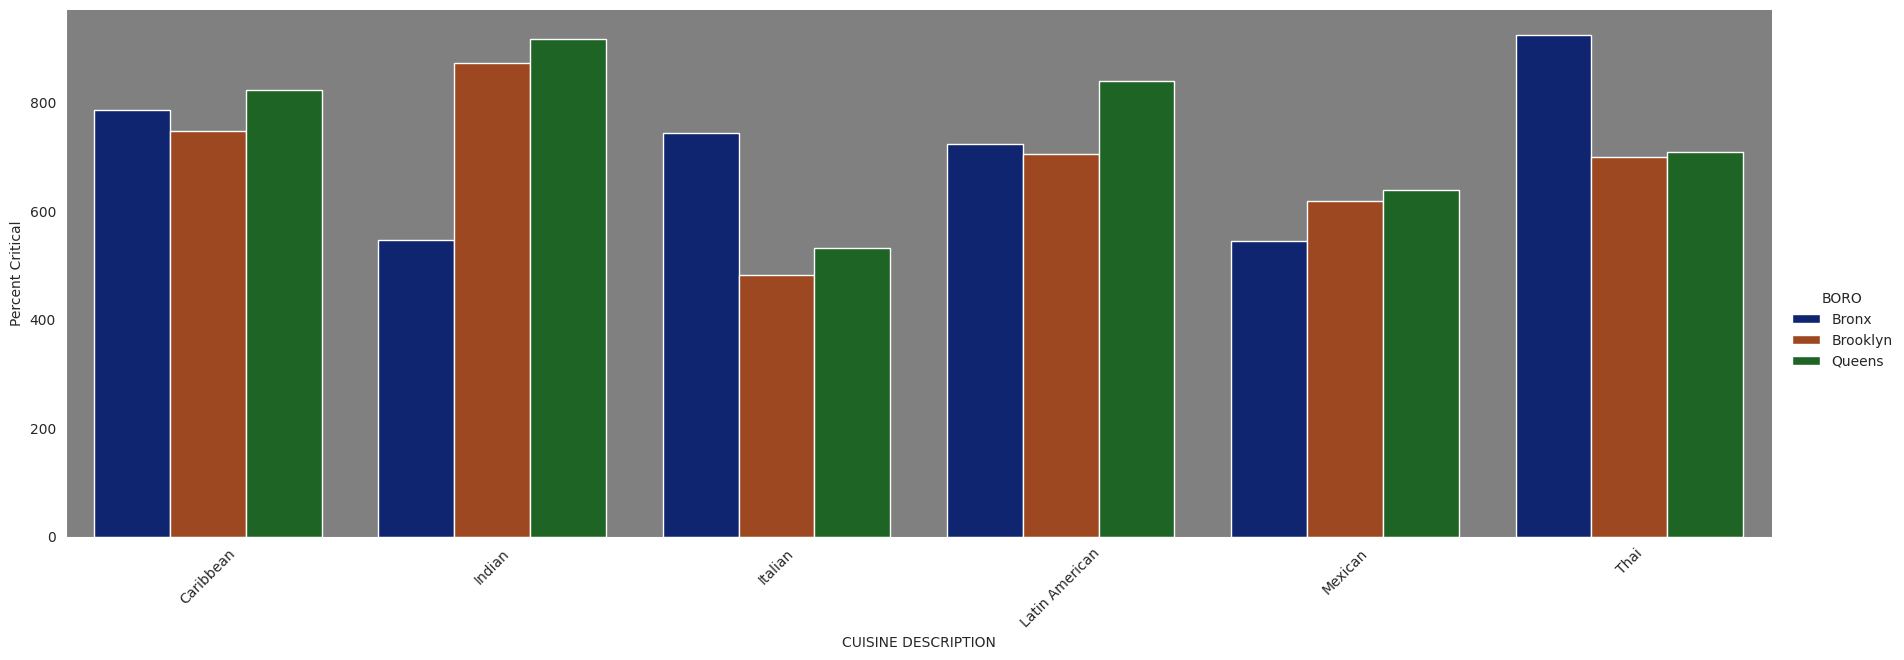

In [111]:
sns.set_style(rc={"axes.facecolor": "grey"})
sns.catplot(data=maxboro, y="Percent Critical", x="CUISINE DESCRIPTION", hue="BORO" ,kind="bar", height=6, aspect=3,palette='dark').set_xticklabels(rotation=45)

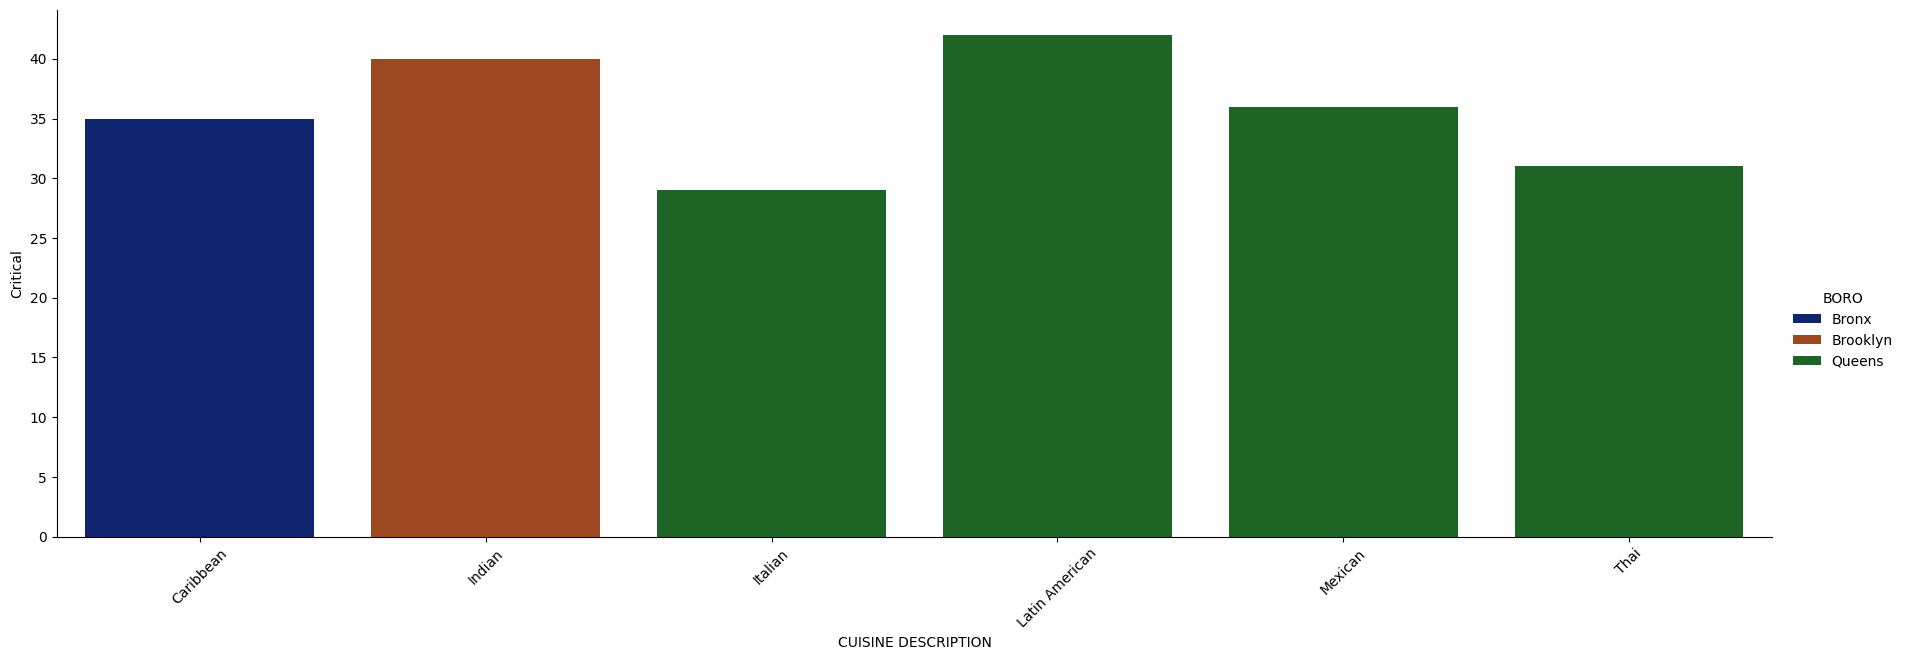

In [106]:
sns.catplot(data=MaxBC, y="Critical", x="CUISINE DESCRIPTION", hue="BORO", kind="bar", height=6, aspect=3, palette='dark').set_xticklabels(rotation=45)

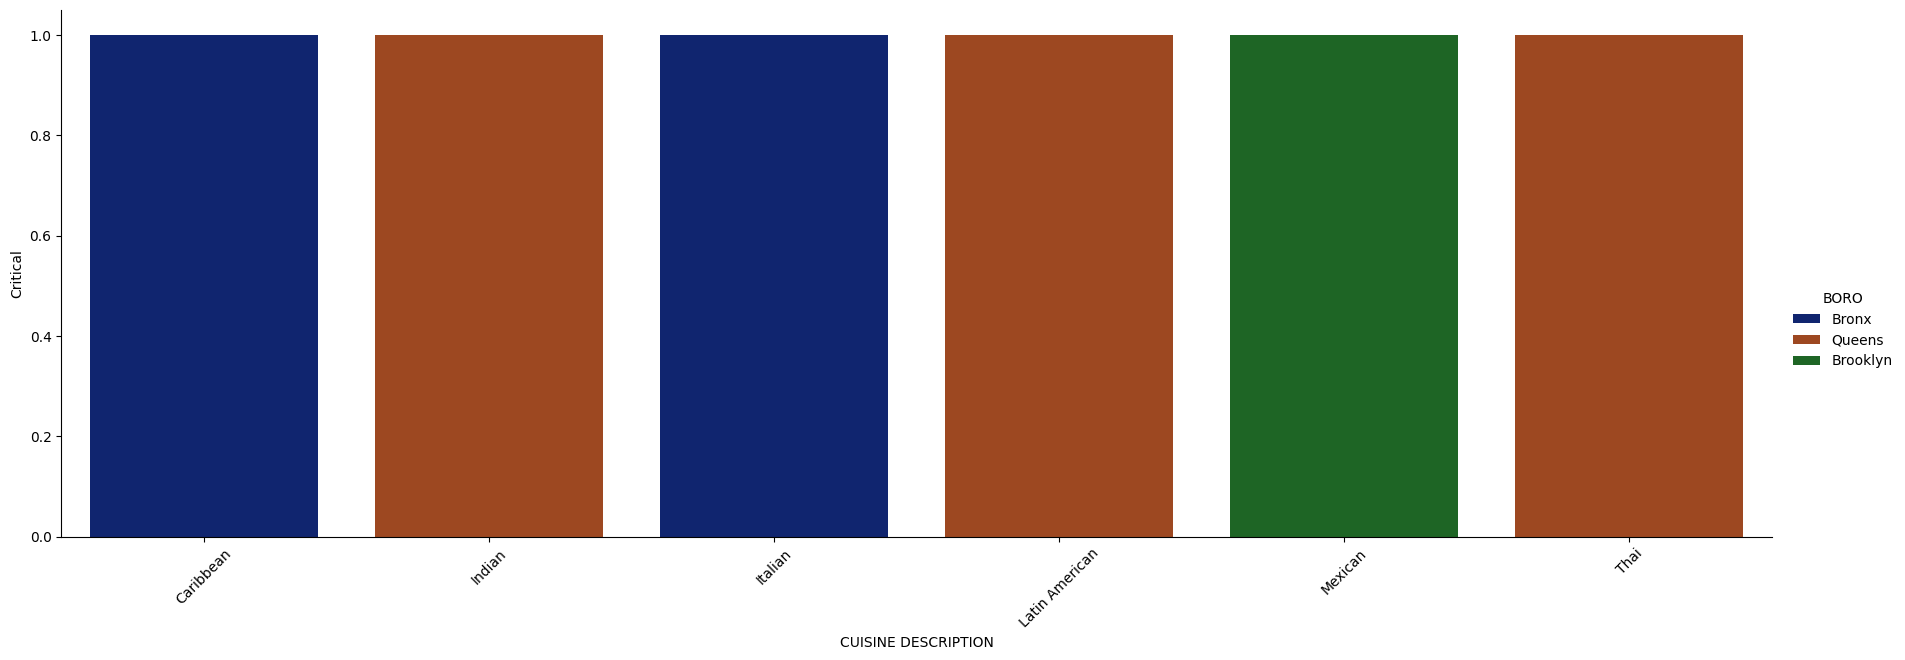

In [107]:
sns.catplot(data=MinBC, y="Critical", x="CUISINE DESCRIPTION", hue="BORO", kind="bar", height=6, aspect=3, palette='dark').set_xticklabels(rotation=45)

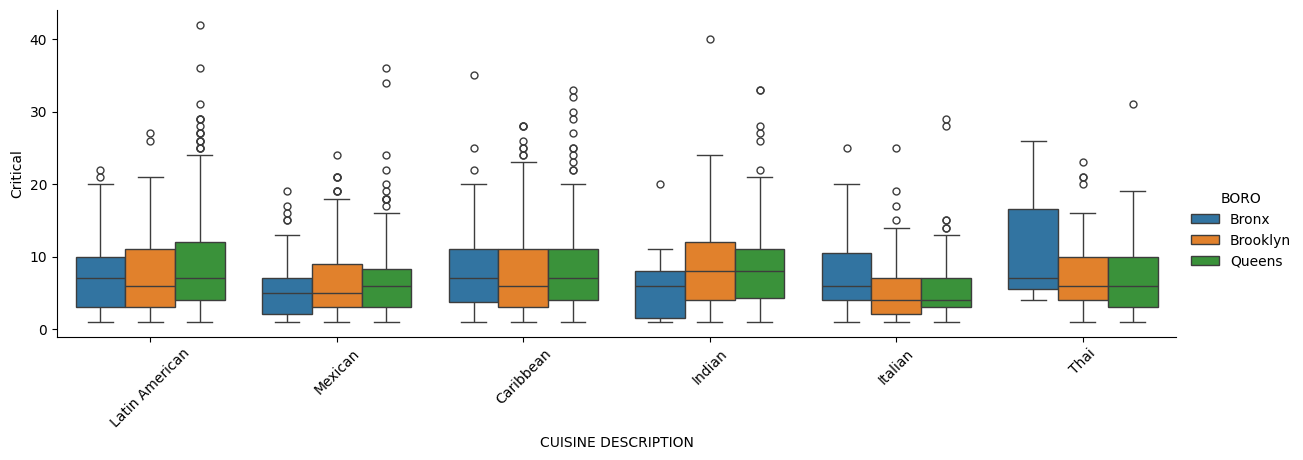

In [67]:
sns.catplot(data=flagfit, y="Critical", x="CUISINE DESCRIPTION", hue="BORO", kind="box", height=4, aspect=3).set_xticklabels(rotation=45)